Importing libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading combined data

In [4]:
df = pd.read_csv("../data/all_countries_clean.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,ethiopia,2015-01-05,1


Verifying countries

In [5]:
df["Country"].unique()

<StringArray>
['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
Length: 5, dtype: str

Aggregating by country

In [6]:
country_stats = df.groupby("Country").agg({
    "T2M": "mean",
    "PRECTOTCORR": "mean",
    "RH2M": "mean"
}).reset_index()

country_stats

,Country,T2M,PRECTOTCORR,RH2M
0,ethiopia,16.096771,3.016690,68.315885
1,kenya,20.450133,1.100035,65.568779
2,nigeria,26.735115,3.645836,85.872586
3,sudan,28.793320,0.321469,30.678091
4,tanzania,26.802536,2.939913,76.995370


Temperature

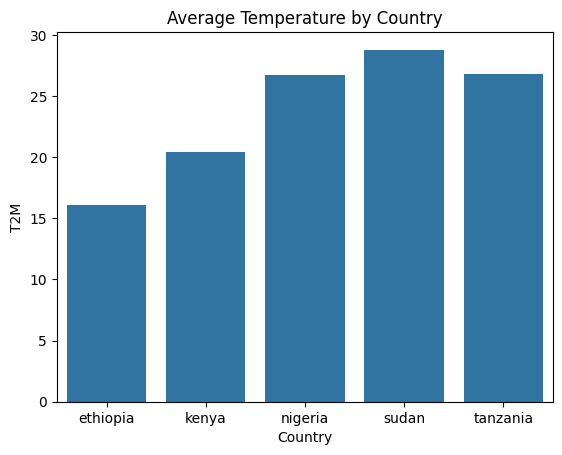

In [7]:
sns.barplot(x="Country", y="T2M", data=country_stats)
plt.title("Average Temperature by Country")
plt.show()

Precipitation

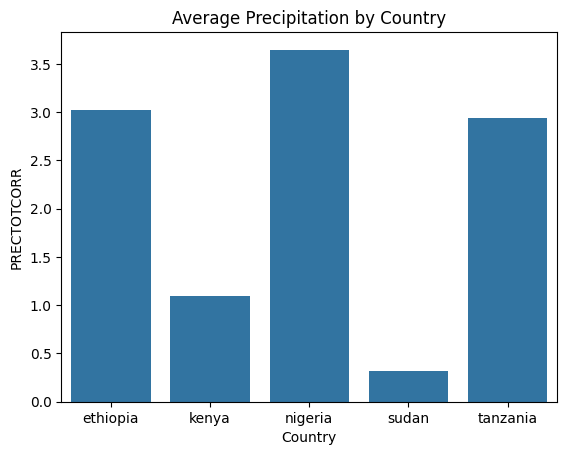

In [8]:
sns.barplot(x="Country", y="PRECTOTCORR", data=country_stats)
plt.title("Average Precipitation by Country")
plt.show()

Defining a score

In [9]:
country_stats["vulnerability_score"] = (
    country_stats["T2M"] * 0.4 +
    country_stats["PRECTOTCORR"] * 0.3 +
    country_stats["RH2M"] * 0.3
)

Sorting

In [10]:
ranking = country_stats.sort_values(by="vulnerability_score", ascending=False)
ranking

,Country,T2M,PRECTOTCORR,RH2M,vulnerability_score
2,nigeria,26.735115,3.645836,85.872586,37.549572
4,tanzania,26.802536,2.939913,76.995370,34.701599
1,kenya,20.450133,1.100035,65.568779,28.180697
0,ethiopia,16.096771,3.016690,68.315885,27.838481
3,sudan,28.793320,0.321469,30.678091,20.817196


Heat and Drought Analysis

Extreme Heat Analysis

Countries with high heat frequency face increased health and productivity risks

Extreme Heat Frequency (Proportion of Days > 35°C):
Country
sudan       0.66501
ethiopia    0.00000
kenya       0.00000
nigeria     0.00000
tanzania    0.00000
Name: extreme_heat, dtype: float64


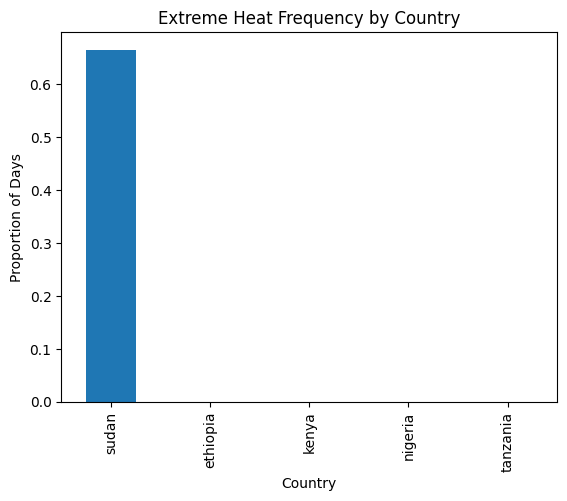

In [13]:
HEAT_THRESHOLD = 35  # °C

df["extreme_heat"] = df["T2M_MAX"] > HEAT_THRESHOLD

heat_freq = (
    df
    .groupby("Country")["extreme_heat"]
    .mean()
    .sort_values(ascending=False)
)

print("Extreme Heat Frequency (Proportion of Days > 35°C):")
print(heat_freq)

heat_freq.plot(kind="bar")
plt.title("Extreme Heat Frequency by Country")
plt.ylabel("Proportion of Days")
plt.xlabel("Country")
plt.show()

Drought Analysis

High drought frequency indicates water and agricultural vulnerability

Drought Frequency (Proportion of Dry Days):
Country
sudan       0.915507
kenya       0.704791
tanzania    0.570681
ethiopia    0.534457
nigeria     0.374710
Name: drought, dtype: float64


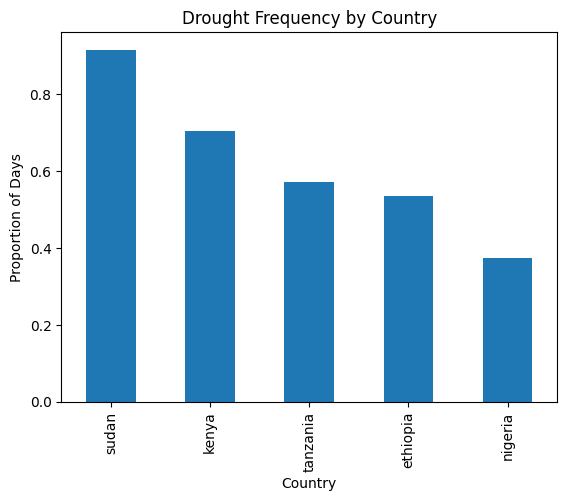

In [ ]:
DROUGHT_THRESHOLD = 1  # mm

df["drought"] = df["PRECTOTCORR"] < DROUGHT_THRESHOLD

drought_freq = (
    df
    .groupby("Country")["drought"]
    .mean()
    .sort_values(ascending=False)
)

print("Drought Frequency (Proportion of Dry Days):")
print(drought_freq)

drought_freq.plot(kind="bar")
plt.title("Drought Frequency by Country")
plt.ylabel("Proportion of Days")
plt.xlabel("Country")
plt.show()

Saving ranking

In [ ]:
ranking.to_csv("../data/vulnerability_ranking.csv", index=False)

COP32 OBSERVATIONS & POLICY IMPLICATIONS
This analysis was conducted to support Ethiopia’s preparation for hosting COP32 in Addis Ababa in 2027. The results provide comparative climate evidence across five African countries using NASA POWER data (2015–2026).

WHAT IS CHANGING?
The data shows clear differences in temperature, precipitation, and humidity patterns across countries. Sudan exhibits consistently high temperatures and low humidity, indicating increasing aridity. Tanzania and Nigeria show higher humidity and precipitation levels, while Ethiopia and Kenya fall in intermediate ranges.

WHAT DID IT CAUSE?
These patterns are associated with increased climate stress:
- High temperatures and low precipitation (e.g., Sudan) suggest increased drought risk and agricultural strain.
- High humidity and precipitation variability (e.g., Nigeria, Tanzania) may indicate flooding risks and infrastructure vulnerability.
- Moderate but variable conditions (e.g., Ethiopia, Kenya) suggest exposure to both drought and rainfall variability.

WHAT DOES IT MEAN?
The findings support several policy and financing priorities:
- Expansion of drought resilience and water management systems in arid regions
- Investment in flood control and early warning systems in high-precipitation zones
- Strengthening climate data infrastructure to improve forecasting and preparedness
- Increased access to adaptation finance and loss-and-damage mechanisms for vulnerable regions

STRATEGIC PSITIONING FOR COP32
Ethiopia can leverage this evidence to:
- Position itself as a data-driven leader in African climate advocacy
- Highlight regional climate diversity and shared vulnerability
- Advocate for tailored adaptation funding rather than one-size-fits-all solutions

This reinforces Ethiopia’s credibility as a host nation capable of presenting negotiation-grade climate evidence.